# Predicting Food Insecurity with Interpretable ML — Method Demo

**What this is.** A self-contained, reproducible demonstration of the pipeline I used on FIES survey data in Mali: gradient-boosted trees and random forests benchmarked against a logistic baseline, hyperparameters tuned by k-fold cross-validation on the training set only, evaluation on a held-out test set, and SHAP values so the model explains *which* household characteristics drive each prediction instead of shipping a black box.

**What this is not.** The real FIES Mali data is confidential (CIRAD/CGIAR survey data), and the AUC obtained there (0.87) belongs to that data. Everything below runs on a **synthetic dataset generated in the first cell** — the point is the method: honest validation, baseline comparison, interpretability.

Runs from scratch in ~1 minute with fixed seeds.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
from xgboost import XGBClassifier
import shap

RNG = np.random.default_rng(7)
N = 4000

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Synthetic household data

Covariates mimicking a household survey (household size, dependency ratio, education, assets, livestock, rainfall shock, market distance, income). The outcome (moderate-or-severe food insecurity) depends non-linearly on them plus noise — enough structure for trees to beat a linear baseline, as in the real data.

In [2]:
df = pd.DataFrame({
    "hh_size":          RNG.poisson(5.5, N).clip(1, 16),
    "dependency_ratio": RNG.beta(2, 3, N),
    "educ_head_years":  RNG.gamma(2.2, 2.2, N).clip(0, 16),
    "asset_index":      RNG.normal(0, 1, N),
    "livestock_tlu":    RNG.exponential(1.4, N).clip(0, 12),
    "rain_shock":       RNG.binomial(1, 0.32, N),
    "dist_market_km":   RNG.exponential(9, N).clip(0.2, 60),
    "log_income":       RNG.normal(6.1, 0.7, N),
})
# Latent risk: non-linear + interactions, then binary outcome
risk = (0.28*df.hh_size/5 + 1.1*df.dependency_ratio - 0.16*df.educ_head_years/4
        - 0.55*df.asset_index - 0.22*np.sqrt(df.livestock_tlu)
        + 0.75*df.rain_shock*(1 - df.asset_index.clip(-1, 1)*0.4)
        + 0.012*df.dist_market_km - 0.85*(df.log_income - 6.1)
        + RNG.normal(0, 0.9, N))
df["food_insecure"] = (risk > np.quantile(risk, 0.62)).astype(int)
print(df.food_insecure.mean().round(3), "insecurity rate"); df.head(3)

0.38 insecurity rate


,hh_size,dependency_ratio,educ_head_years,asset_index,livestock_tlu,rain_shock,dist_market_km,log_income,food_insecure
0,6,0.239600,5.764720,-0.397739,0.002612,0,1.133302,6.570093,0
1,6,0.489575,1.790944,0.431248,4.918305,0,7.456950,6.307632,0
2,8,0.424067,3.829967,-0.240964,0.494936,0,10.854065,5.908789,1


## 2. Honest split and baseline

Stratified 75/25 train/test split. The logistic baseline answers the question the real project asked first: *does ML actually beat the standard econometric approach here, or are we adding complexity for nothing?*

In [3]:
features = df.columns.drop("food_insecure").tolist()
X_tr, X_te, y_tr, y_te = train_test_split(df[features], df.food_insecure,
                                          test_size=0.25, stratify=df.food_insecure, random_state=7)

logit = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logit.fit(X_tr, y_tr)
auc_logit = roc_auc_score(y_te, logit.predict_proba(X_te)[:, 1])
print(f"Logistic baseline — test AUC: {auc_logit:.3f}")

Logistic baseline — test AUC: 0.843


## 3. Tuned ensemble models (CV on training data only)

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

rf = GridSearchCV(RandomForestClassifier(random_state=7, n_jobs=-1),
                  {"n_estimators": [300], "max_depth": [6, 10, None],
                   "min_samples_leaf": [1, 5, 20]},
                  cv=cv, scoring="roc_auc", n_jobs=-1).fit(X_tr, y_tr)

xgb = GridSearchCV(XGBClassifier(random_state=7, eval_metric="logloss", n_jobs=-1),
                   {"n_estimators": [400], "max_depth": [3, 5],
                    "learning_rate": [0.03, 0.1], "subsample": [0.8, 1.0]},
                   cv=cv, scoring="roc_auc", n_jobs=-1).fit(X_tr, y_tr)

for name, m in [("Random Forest", rf), ("XGBoost", xgb)]:
    auc = roc_auc_score(y_te, m.predict_proba(X_te)[:, 1])
    print(f"{name:14s} best CV AUC {m.best_score_:.3f} | test AUC {auc:.3f} | {m.best_params_}")

Random Forest  best CV AUC 0.852 | test AUC 0.829 | {'max_depth': 10, 'min_samples_leaf': 5, 'n_estimators': 300}
XGBoost        best CV AUC 0.855 | test AUC 0.834 | {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 400, 'subsample': 1.0}


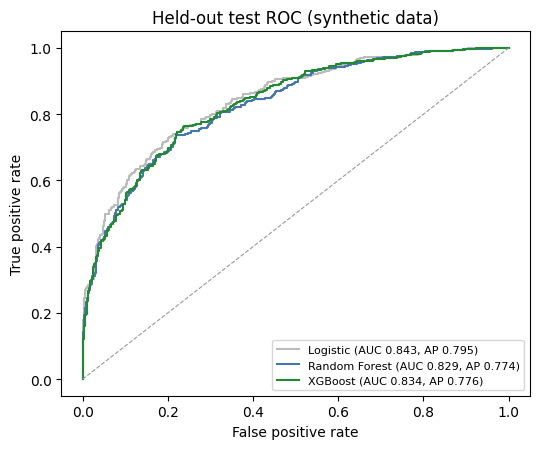

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 4.6))
for name, m, col in [("Logistic", logit, "#BBBBBB"), ("Random Forest", rf, "#4477AA"), ("XGBoost", xgb, "#228833")]:
    p = m.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, p)
    ax.plot(fpr, tpr, color=col,
            label=f"{name} (AUC {roc_auc_score(y_te, p):.3f}, AP {average_precision_score(y_te, p):.3f})")
ax.plot([0, 1], [0, 1], "--", color="#999", lw=0.8)
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("Held-out test ROC (synthetic data)"); ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.savefig("figures/ml_roc.png", dpi=120, bbox_inches="tight"); plt.show()

## 4. Interpretability: SHAP

For targeting decisions, "the model says this household is at risk" is not enough — programme officers need to know *why*. SHAP values decompose every prediction into feature contributions.

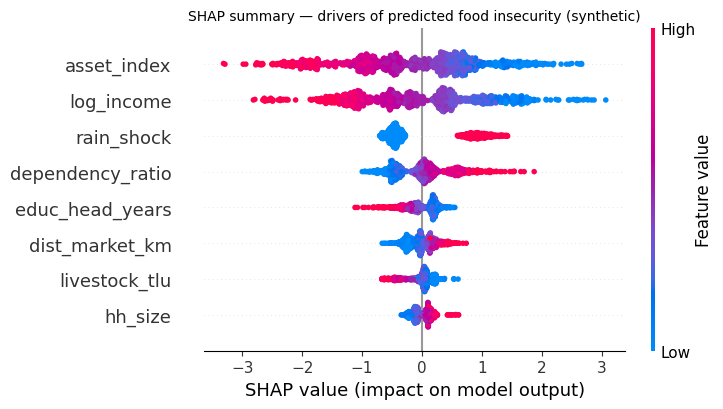

In [6]:
explainer = shap.TreeExplainer(xgb.best_estimator_)
sv = explainer.shap_values(X_te)
shap.summary_plot(sv, X_te, show=False, plot_size=(7.5, 4.2))
plt.title("SHAP summary — drivers of predicted food insecurity (synthetic)", fontsize=10)
plt.tight_layout(); plt.savefig("figures/ml_shap.png", dpi=120, bbox_inches="tight"); plt.show()

## Takeaway

The pipeline demonstrates the three habits that mattered in the real project: benchmark ML against the standard approach before adopting it, tune only inside the training folds and report held-out metrics, and ship explanations with predictions. Note the result on this synthetic stand-in: the logistic baseline actually edges out both tree ensembles — exactly the kind of outcome the benchmark-first habit is designed to surface. On the real FIES Mali data, where interactions and non-linearities are stronger, the tuned ensembles reached AUC 0.87 and did beat the baseline; when they don't, the honest answer is to keep the simpler model.